In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm 
import scipy 

In [2]:
#Define the quantities of the stocks and import their files 
quantities={'IBM':5000,'NFLX':2000,'SPOT':1500,'XOM':5000,'MCD':2500}
stocks={'IBM':'IBM.csv','NFLX':'Netflix.csv','SPOT':'Spotify.csv','XOM':'Exxon_Mobil.csv','MCD':'McDonalds.csv'}
index='S&P_500.csv'
futures='S&P_500_Futures.csv'

start_date = '2024-11-01'
end_date   = '2025-10-31'





In [3]:
#Define a function that reads all the files 
def read_investing_csv(path):
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df['Price'] = df['Price'].replace(',', '', regex=True).astype(float)
    df = df.sort_values('Date')
    df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
    df = df.set_index('Date')
    return df



In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [5]:
# Stocks prices in one matrix 
prices_equities = []
for ticker, fname in stocks.items():
    df = read_investing_csv(fname)
    prices_equities.append(df['Price'].rename(ticker))

prices_equities = pd.concat(prices_equities, axis=1)
print(prices_equities.tail())

               IBM    NFLX    SPOT     XOM     MCD
Date                                              
2025-10-27  313.09  109.46  657.80  115.94  310.00
2025-10-28  312.57  110.25  653.43  115.03  306.40
2025-10-29  308.21  110.04  665.67  116.45  302.35
2025-10-30  310.06  108.90  656.68  114.69  302.43
2025-10-31  307.41  111.89  655.32  114.36  298.43


In [6]:
# Daily returns of the stocks
returns_equities = prices_equities.pct_change().dropna()
print(returns_equities.tail())


                 IBM      NFLX      SPOT       XOM       MCD
Date                                                        
2025-10-27  0.018311 -0.000091  0.018613  0.004766  0.013768
2025-10-28 -0.001661  0.007217 -0.006643 -0.007849 -0.011613
2025-10-29 -0.013949 -0.001905  0.018732  0.012345 -0.013218
2025-10-30  0.006002 -0.010360 -0.013505 -0.015114  0.000265
2025-10-31 -0.008547  0.027456 -0.002071 -0.002877 -0.013226


In [7]:
# Portfolio value daily
avg_values = {}
for ticker, q in quantities.items():
    prices_equities[ticker + '_value'] = prices_equities[ticker] * q
    avg_values[ticker] = (prices_equities[ticker] * q).mean()

portfolio_value = prices_equities[[c for c in prices_equities.columns 
                                   if c.endswith('_value')]].sum(axis=1)
portfolio_value.name = 'Portfolio_Value'

# Portfolio returns
portfolio_returns = portfolio_value.pct_change().dropna()
portfolio_returns.name = 'Portfolio_Return'

print(portfolio_value.tail())
print(portfolio_returns.tail())


Date
2025-10-27    4125770.0
2025-10-28    4104645.0
2025-10-29    4097760.0
2025-10-30    4082645.0
2025-10-31    4061685.0
Name: Portfolio_Value, dtype: float64
Date
2025-10-27    0.014616
2025-10-28   -0.005120
2025-10-29   -0.001677
2025-10-30   -0.003689
2025-10-31   -0.005134
Name: Portfolio_Return, dtype: float64


In [8]:
# S&P 500 index prices
spx = read_investing_csv('S&P_500.csv')
spx_price = spx['Price'].rename('SP500')

print(spx_price.tail())


Date
2025-10-27    6875.16
2025-10-28    6890.89
2025-10-29    6890.59
2025-10-30    6822.34
2025-10-31    6840.20
Name: SP500, dtype: float64


In [9]:
# S&P 500 daily returns
spx_returns = spx_price.pct_change().dropna()
spx_returns.name = 'SP500_Return'

print(spx_returns.tail())


Date
2025-10-27    0.012290
2025-10-28    0.002288
2025-10-29   -0.000044
2025-10-30   -0.009905
2025-10-31    0.002618
Name: SP500_Return, dtype: float64


In [10]:
# S&P 500 futures daily returns
spx_fut_df = read_investing_csv('S&P_500_Futures.csv')
spx_fut = spx_fut_df['Price'].rename('SP500_FUT')
print(spx_fut_df.tail())


              Price      Open      High       Low   Vol. Change %
Date                                                             
2025-10-27  6908.25  6,881.00  6,916.25  6,865.75  1.19M    1.19%
2025-10-28  6925.75  6,914.00  6,944.75  6,901.50  1.22M    0.25%
2025-10-29  6922.75  6,929.25  6,952.00  6,882.25  1.54M   -0.04%
2025-10-30  6855.50  6,906.50  6,953.75  6,851.00  1.82M   -0.97%
2025-10-31  6874.00  6,897.00  6,918.50  6,843.50  1.76M    0.27%


In [11]:
# S&P500 Futures andd returns in one matrix
data_for_beta = returns_equities.join(spx_returns, how='inner')
print(data_for_beta.tail())


                 IBM      NFLX      SPOT       XOM       MCD  SP500_Return
Date                                                                      
2025-10-27  0.018311 -0.000091  0.018613  0.004766  0.013768      0.012290
2025-10-28 -0.001661  0.007217 -0.006643 -0.007849 -0.011613      0.002288
2025-10-29 -0.013949 -0.001905  0.018732  0.012345 -0.013218     -0.000044
2025-10-30  0.006002 -0.010360 -0.013505 -0.015114  0.000265     -0.009905
2025-10-31 -0.008547  0.027456 -0.002071 -0.002877 -0.013226      0.002618


In [12]:
# Calculation of stocks beta and OLS Regression
from scipy.stats import linregress
import numpy as np

def compute_beta_linregress(asset_returns, market_returns):
    """Linear regression: R_asset = α + β * R_market"""
    slope, intercept, r_value, p_value, std_err = linregress(market_returns, asset_returns)
    return slope, intercept, r_value**2, p_value, std_err

tickers = ['IBM', 'NFLX', 'SPOT', 'XOM', 'MCD']
betas_linreg = {}
linreg_results = {}

print("Beta Calculations (OLS Regression)")
print("="*40)

for ticker in tickers:
    asset_ret = data_for_beta[ticker].values
    market_ret = data_for_beta['SP500_Return'].values

    beta, alpha, r_sq, pval, std_err = compute_beta_linregress(asset_ret, market_ret)

    betas_linreg[ticker] = beta
    linreg_results[ticker] = {
        'beta': beta,
        'alpha': alpha,
        'r_squared': r_sq,
        'p_value': pval,
        'std_err': std_err
    }

    print(f"\n{ticker}:")
    print(f" β = {beta:.4f}, R² = {r_sq:.4f}, p-value = {pval:.6f}")








Beta Calculations (OLS Regression)

IBM:
 β = 0.7557, R² = 0.2205, p-value = 0.000000

NFLX:
 β = 0.9191, R² = 0.2779, p-value = 0.000000

SPOT:
 β = 1.1128, R² = 0.2147, p-value = 0.000000

XOM:
 β = 0.5470, R² = 0.1931, p-value = 0.000000

MCD:
 β = 0.1976, R² = 0.0435, p-value = 0.000926


In [13]:
#Portfolio beta 
weights_new = {t: avg_values[t] / sum(avg_values.values()) for t in tickers}
beta_portfolio_ols = sum(weights_new[t] * betas_linreg[t] for t in tickers)

print(f"\nPortfolio Beta (OLS) = {beta_portfolio_ols:.4f}")



Portfolio Beta (OLS) = 0.7081


In [14]:
# Correlation with  SP500
correlations = data_for_beta[['IBM', 'NFLX', 'SPOT', 'XOM', 'MCD']].corrwith(data_for_beta['SP500_Return'])

print("Correlations with S&P 500:")
print(correlations)



Correlations with S&P 500:
IBM     0.469571
NFLX    0.527145
SPOT    0.463381
XOM     0.439443
MCD     0.208628
dtype: float64


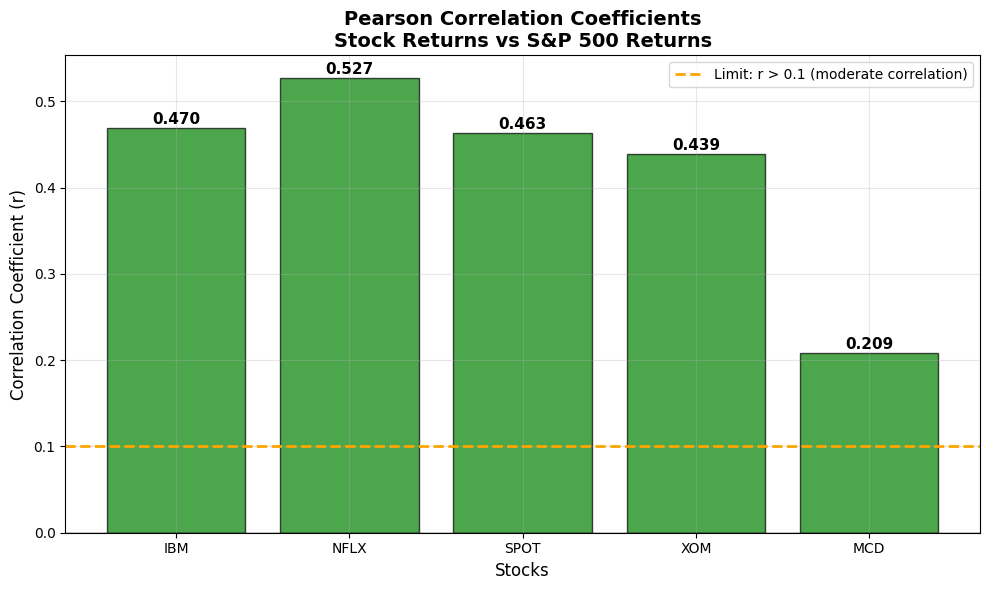

In [15]:
# Correlation Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
stocks = correlations.index
values = correlations.values

# Colors: Red for low correlation (<0.1), green for high
colors = ['red' if v < 0.1 else 'green' for v in values]
bars = ax.bar(stocks, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

ax.set_title('Pearson Correlation Coefficients\nStock Returns vs S&P 500 Returns', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlation Coefficient (r)', fontsize=12)
ax.set_xlabel('Stocks', fontsize=12)
ax.axhline(y=0.1, color='orange', linestyle='--', linewidth=2, label='Limit: r > 0.1 (moderate correlation)')
ax.axhline(y=0, color='black', linewidth=1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Putting prices in every bar
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


In [16]:
#Price of the contract e‑mini S&P 500
futures_price_ref = spx_fut.mean()   # mean
multiplier = 50                      # e-mini multiplier
V_fut = futures_price_ref * multiplier

V_port = portfolio_value.loc['2025-10-31']   
print("Mean of the futures:", futures_price_ref)
print("Contract value:", V_fut)
print("Portfolio value:", V_port)


Mean of the futures: 6112.771607843138
Contract value: 305638.5803921569
Portfolio value: 4061685.0000000005


In [17]:
#Number of contracts with beta 
beta_portfolio = 0.7081
N_fut = beta_portfolio * V_port / V_fut
print("Number of contracts:", N_fut)
print("Rounded:", round(N_fut))


Number of contracts: 9.4100657868839
Rounded: 9


In [18]:
#Daily returns of the futures
spx_fut_returns = spx_fut.pct_change().dropna()
spx_fut_returns


Date
2024-11-04   -0.002605
2024-11-05    0.012014
2024-11-06    0.025119
2024-11-07    0.007636
2024-11-08    0.003581
                ...   
2025-10-27    0.011901
2025-10-28    0.002533
2025-10-29   -0.000433
2025-10-30   -0.009714
2025-10-31    0.002699
Name: SP500_FUT, Length: 254, dtype: float64

In [19]:
#Common dates of portfolio and futures
common_dates = portfolio_returns.index.intersection(spx_fut_returns.index)
port_ret = portfolio_returns.loc[common_dates]
fut_ret  = spx_fut_returns.loc[common_dates]

#Ratio of hedge k
k = N_fut * V_fut / V_port

#Hedged returns of the portfolio 
hedged_returns = port_ret - k * fut_ret

#Volatility comparison
unhedged_vol = portfolio_returns.std() * 100
hedged_vol   = hedged_returns.std() * 100
ratio_vol    = hedged_vol / unhedged_vol

print("-----CAPM Hedge with Futures-----")
print(f"Number of contracts (rounded): {round(N_fut)}")
print(f"Ratio of hedge k: {k:.3f}")
print(f"Vol without hedge: {unhedged_vol:.2f}%")
print(f"Vol with hedge: {hedged_vol:.2f}%")
print(f"Vol ratio (hedged/unhedged): {ratio_vol:.3f}")



-----CAPM Hedge with Futures-----
Number of contracts (rounded): 9
Ratio of hedge k: 0.708
Vol without hedge: 1.27%
Vol with hedge: 0.98%
Vol ratio (hedged/unhedged): 0.770


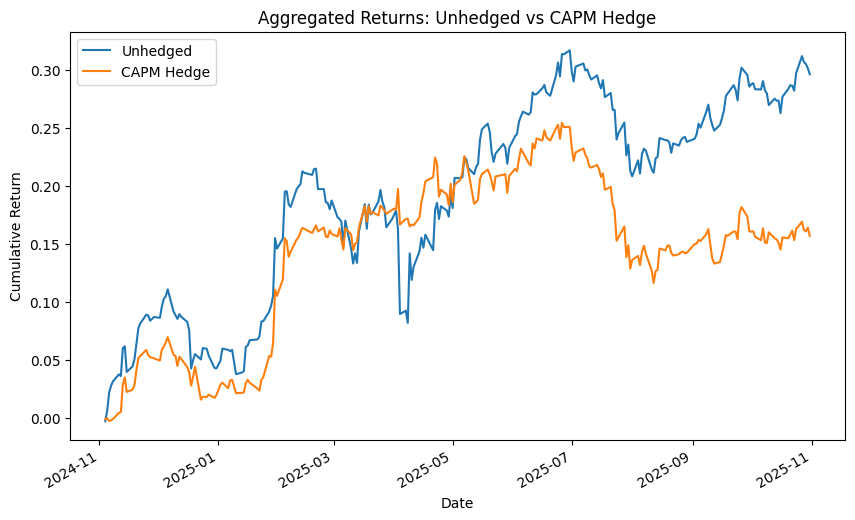

In [20]:
#Comparison plot
import matplotlib.pyplot as plt 
comparison = pd.DataFrame({
    'Unhedged': port_ret.cumsum(),
    'CAPM Hedge': hedged_returns.cumsum()
})
comparison.plot(figsize=(10,6), title='Aggregated Returns: Unhedged vs CAPM Hedge')
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.show()



In [21]:
# Static optimal hedge ratio h*
cov_pf_fut = np.cov(port_ret, fut_ret)[0, 1]
var_fut    = np.var(fut_ret)
h_star_static = cov_pf_fut / var_fut

print("Στατικό optimal hedge ratio h*:", round(h_star_static, 3))


Στατικό optimal hedge ratio h*: 0.679


In [22]:
#Number of contracts with optimal hedge ratio
N_star = h_star_static * V_port / V_fut
print("Optimal N* (theoritical):", N_star)
print("Optimal N* (rounded):", round(N_star))


Optimal N* (theoritical): 9.023896756276915
Optimal N* (rounded): 9


In [23]:
#Hedged returns wtih optimal hedge ratio
k_star = N_star * V_fut / V_port   # value of hedge με N*
hedged_returns_opt = port_ret - k_star * fut_ret

unhedged_vol = portfolio_returns.std() * 100
hedged_opt_vol = hedged_returns_opt.std() * 100

print("Vol without hedge: {:.2f}%".format(unhedged_vol))
print("Vol with optimal hedge: {:.2f}%".format(hedged_opt_vol))
print("Vol ratio (optimal/without): {:.3f}".format(hedged_opt_vol / unhedged_vol))


Vol without hedge: 1.27%
Vol with optimal hedge: 0.98%
Vol ratio (optimal/without): 0.769


In [24]:
#Dynamic model

import statsmodels.api as sm
#Ignore warnings from pandas/NumPy
import warnings
warnings.filterwarnings("ignore")


window = 60  #60 working days
h_t = []

for i in range(window, len(port_ret)):
    y = port_ret.iloc[i-window:i]
    x = fut_ret.iloc[i-window:i]
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()
    h_t.append(model.params[1])  

# Series with dynamic hedge ratio aligned with the dates after the window
h_t = pd.Series(h_t, index=port_ret.index[window:])

# Dynamic ratio of hedge value
k_t = h_t * V_fut / V_port

# Returns in the same vector
port_dyn = port_ret.loc[h_t.index]
fut_dyn  = fut_ret.loc[h_t.index]

hedged_dyn = port_dyn - k_t * fut_dyn

hedged_dyn_vol = hedged_dyn.std() * 100
print("Vol with dynamic hedge: {:.2f}%".format(hedged_dyn_vol))
print(" Vol ratio (dynamic/without): {:.3f}".format(hedged_dyn_vol / unhedged_vol))




Vol with dynamic hedge: 1.26%
 Vol ratio (dynamic/without): 0.992


In [25]:
# Rolling for static model (in order to do comparison plot)
h_static_rolling = []
window = 60
for i in range(window, len(port_ret)):
    y_roll = port_ret.iloc[i-window:i]
    x_roll = fut_ret.iloc[i-window:i]
    cov_roll = np.cov(y_roll, x_roll)[0,1]
    var_roll = np.var(x_roll)
    h_static_rolling.append(cov_roll / var_roll)

h_static_rolling = pd.Series(h_static_rolling, index=h_t.index)


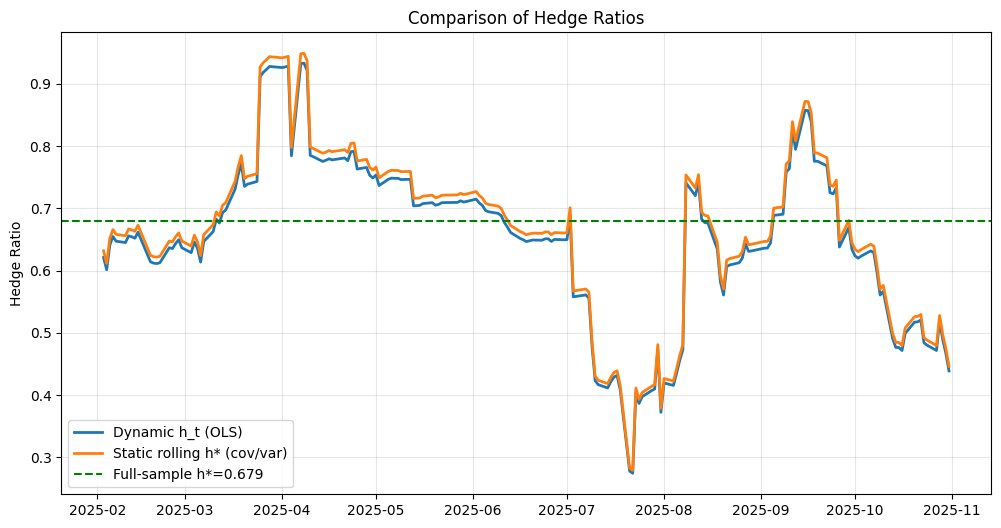

In [26]:
#Plot static model with static h* and dynamic ht*
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(h_t.index, h_t.values, label='Dynamic h_t (OLS)', linewidth=2)
plt.plot(h_static_rolling.index, h_static_rolling.values, 
         label='Static rolling h* (cov/var)', linewidth=2)
plt.axhline(y=h_star_static, color='green', linestyle='--', 
            label=f'Full-sample h*={h_star_static:.3f}')
plt.title('Comparison of Hedge Ratios')
plt.ylabel('Hedge Ratio'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()



In [27]:
# Delta Neutral Portfolio with Puts
import numpy as np
from scipy.stats import norm

# Values for για Black-Scholes
def black_scholes_put(S, K, T, r, sigma):
    """
    S: Current stock price
    K: Strike price
    T: Time until Clearing (years)
    r: Risk free interest rate (e.g 0.03 = 3%)
    sigma: Volatility
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    put_delta = -norm.cdf(-d1)  # Delta for put
    
    return put_price, put_delta




In [28]:
#Calculate delta for IBM 
S = prices_equities['IBM'].iloc[-1]  # Recent price
K = S * 0.95  # Strike 5% under of current price
T = 30/365  # 30 days till Clearing
r = 0.03  # 3% interest rate
sigma = returns_equities['IBM'].std() * np.sqrt(252)  # Annual Volatility

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Put option IBM: Price={put_price:.2f}, Δ={put_delta:.4f}")

Put option IBM: Price=4.29, Δ=-0.2548


In [29]:
#Calculate delta for Netflix
S = prices_equities['NFLX'].iloc[-1]  # Recent price
K = S * 0.95  # Strike 5% under of current price
T = 30/365  # 30 days till Clearing
r = 0.03  # 3% interest rate
sigma = returns_equities['NFLX'].std() * np.sqrt(252)  # Annual Volatility

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Put option Netflix: Price={put_price:.2f}, Δ={put_delta:.4f}")

Put option Netflix: Price=1.83, Δ=-0.2691


In [30]:
#Calculate delta for Spotify
S = prices_equities['SPOT'].iloc[-1]  # Recent price
K = S * 0.95  # Strike 5% under of current price
T = 30/365  # 30 days till Clearing
r = 0.03  # 3% interest rate
sigma = returns_equities['SPOT'].std() * np.sqrt(252)  # Annual Volatility

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Put option Spotify: Price={put_price:.2f}, Δ={put_delta:.4f}")

Put option Spotify: Price=18.78, Δ=-0.3164


In [31]:
#Calculate delta for Exxon Mobil
S = prices_equities['XOM'].iloc[-1]  # Recent price
K = S * 0.95  # Strike 5% under of current price
T = 30/365  # 30 days till Clearing
r = 0.03  # 3% interest rate
sigma = returns_equities['XOM'].std() * np.sqrt(252)  # Annual Volatility

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Put option Exxon: Price={put_price:.2f}, Δ={put_delta:.4f}")

Put option Exxon: Price=0.91, Δ=-0.2033


In [32]:
#Calculate delta for McDonalds
S = prices_equities['MCD'].iloc[-1]  # Recent price
K = S * 0.95  # Strike 5% under of current price
T = 30/365  # 30 days till Clearing
r = 0.03  # 3% interest rate
sigma = returns_equities['MCD'].std() * np.sqrt(252)  # Annual Volatility

put_price, put_delta = black_scholes_put(S, K, T, r, sigma)
print(f"Put option McDonalds: Price={put_price:.2f}, Δ={put_delta:.4f}")

Put option McDonalds: Price=1.14, Δ=-0.1419


In [33]:
#Portoflio delta 
def calculate_stock_delta(portfolio_value, stock_prices, quantities):
    """
    Calculates the delta  of the equity portfolio.
    Stock delta = 1 (for each stock)
    """
    total_delta = 0
    stock_deltas = {}
    
    for ticker in quantities.keys():
        stock_delta = 1.0
        total_stock_delta = quantities[ticker] * stock_delta
        stock_deltas[ticker] = total_stock_delta
        total_delta += total_stock_delta
    
    return total_delta, stock_deltas

# Calculate 
portfolio_delta, stock_deltas = calculate_stock_delta(portfolio_value, prices_equities, quantities)
print(f"\nTotal delta of equity portfolio: {portfolio_delta:.0f}")
print("Delta in stocks:")
for ticker, delta in stock_deltas.items():
    print(f"  {ticker}: {delta:.0f} shares -> D={delta:.0f}")


Total delta of equity portfolio: 16000
Delta in stocks:
  IBM: 5000 shares -> D=5000
  NFLX: 2000 shares -> D=2000
  SPOT: 1500 shares -> D=1500
  XOM: 5000 shares -> D=5000
  MCD: 2500 shares -> D=2500


In [34]:
# Delta of stocks
delta_stocks = {
    'IBM': 5000,
    'NFLX': 2000,
    'SPOT': 1500,
    'XOM': 5000,
    'MCD': 2500
}

# Delta put option
puts_delta = {
    'IBM': -0.2548,
    'NFLX': -0.2691,
    'SPOT': -0.3164,
    'XOM': -0.2033,
    'MCD': -0.1419
}

# Number of shares per contracts (τυπικά 100)
shares_per_contract = 100

puts_contracts_needed = {}
for ticker in delta_stocks:
    contracts = delta_stocks[ticker] / abs(puts_delta[ticker]) / shares_per_contract
    puts_contracts_needed[ticker] = round(contracts)
    
print("Number of put contracts for delta-neutral:")
for ticker, n in puts_contracts_needed.items():
    print(f"{ticker}: {n} συμβόλαια")


Number of put contracts for delta-neutral:
IBM: 196 συμβόλαια
NFLX: 74 συμβόλαια
SPOT: 47 συμβόλαια
XOM: 246 συμβόλαια
MCD: 176 συμβόλαια


In [35]:

#calculate delta neutral portfolio 

stocks = {
    'IBM': 5000,
    'NFLX': 2000,
    'SPOT': 1500,
    'XOM': 5000,
    'MCD': 2500
}


puts_delta = {
    'IBM': -0.2548,
    'NFLX': -0.2691,
    'SPOT': -0.3164,
    'XOM': -0.2033,
    'MCD': -0.1419
}


puts_contracts = {
    'IBM': 196,
    'NFLX': 74,
    'SPOT': 47,
    'XOM': 246,
    'MCD': 176
}


delta_stocks = sum(stocks.values())
print(f"Total stocks delta: {delta_stocks}")


delta_puts_total = sum(puts_delta[s]*puts_contracts[s] for s in puts_delta)
print(f"Total puts delta : {delta_puts_total:.2f}")

delta_adjustment = - (delta_stocks + delta_puts_total)
if delta_adjustment >= 0:
    action = "Buy"
else:
    action = "Short"
print(f"\nFor delta-neutral we need: {action} {abs(delta_adjustment):.0f} total of shares")


Total stocks delta: 16000
Total puts delta : -159.71

For delta-neutral we need: Short 15840 total of shares


In [36]:
#Calculate Ν for delta neutral portfolio 

delta_stocks = 16000

put_deltas = [-0.2548,-0.2691, -0.3164,-0.2033,-0.1419]


sum_put_deltas = sum(put_deltas)

contract_size = 100

N = -delta_stocks / (contract_size * sum_put_deltas)
N_contracts = np.ceil(N)

print(f"We need {int(N_contracts)} put contracts for delta-neutral χαρτοφυλάκιο")

total_delta = delta_stocks + N_contracts * contract_size * sum_put_deltas
print(f"Τελικό συνολικό delta: {total_delta:.2f}")


We need 135 put contracts for delta-neutral χαρτοφυλάκιο
Τελικό συνολικό delta: -4.25


In [37]:
# Adjustment in 16 December
dec_16_date = '2024-12-16'

if dec_16_date in prices_equities.index:
    print(f"\n--- Adjustment in {dec_16_date} ---")

    prices_dec16 = prices_equities.loc[dec_16_date]

  
    new_portfolio_delta = sum(quantities.values())

    print("Prices in 16/12:")
    for ticker in tickers:
        print(f"  {ticker}: {prices_dec16[ticker]:.2f}")

    print(f"New stocks delta: {new_portfolio_delta:.0f}")


    new_sum_put_deltas = sum(put_deltas)  

    total_put_delta = N_contracts * contract_size * new_sum_put_deltas

 
    shares_target = -total_put_delta
    shares_to_trade = new_portfolio_delta - shares_target

    print("\nNew Hedging:")
    print(f"  Total delta puts: {total_put_delta:.2f}")
    print(f"  Needed shares for delta-neutral: {shares_target:.0f}")
    print(f"  Adjustment (short if +): {shares_to_trade:.0f}")

else:
    print(f"Date {dec_16_date} not found in dataset")



--- Adjustment in 2024-12-16 ---
Prices in 16/12:
  IBM: 229.33
  NFLX: 92.11
  SPOT: 484.90
  XOM: 108.47
  MCD: 297.71
New stocks delta: 16000

New Hedging:
  Total delta puts: -16004.25
  Needed shares for delta-neutral: 16004
  Adjustment (short if +): -4


In [41]:

#Caluclate hedged portfolio returns
N_puts = portfolio_value / (put_price * contract_size)
def calculate_hedged_portfolio_return(portfolio_returns, put_returns, N_puts, contract_size=100):
    """
    Hedged_return = Stocks_returns + (N_puts * put_return)
    """
    
    put_returns_simulated = -0.7 * portfolio_returns
    

    puts_contribution = (N_puts * put_returns_simulated) / portfolio_value
    
  
    hedged_returns = portfolio_returns + puts_contribution
    
    return hedged_returns


hedged_returns = calculate_hedged_portfolio_return(
    portfolio_returns, 
    portfolio_returns,  
    N_puts
)


unhedged_vol = portfolio_returns.std() * np.sqrt(252) * 100  
hedged_vol = hedged_returns.std() * np.sqrt(252) * 100

print(f"\n=== Impact of the Delta-Neutral Strategy ===")
print(f"Unhedged Volatility: {unhedged_vol:.2f}%")
print(f"Volatility with Hedging: {hedged_vol:.2f}%")
print(f"Reduction of volatility: {((unhedged_vol - hedged_vol) / unhedged_vol * 100):.1f}%")


unhedged_mean_return = portfolio_returns.mean() * 252 * 100
hedged_mean_return = hedged_returns.mean() * 252 * 100

print(f"\nAverage annual return without hedging: {unhedged_mean_return:.2f}%")
print(f"Average annual return with hedging: {hedged_mean_return:.2f}%")
print(f"Difference: {hedged_mean_return - unhedged_mean_return:.2f}%")


=== Impact of the Delta-Neutral Strategy ===
Unhedged Volatility: 20.12%
Volatility with Hedging: 20.09%
Reduction of volatility: 0.1%

Average annual return without hedging: 29.97%
Average annual return with hedging: 29.93%
Difference: -0.04%


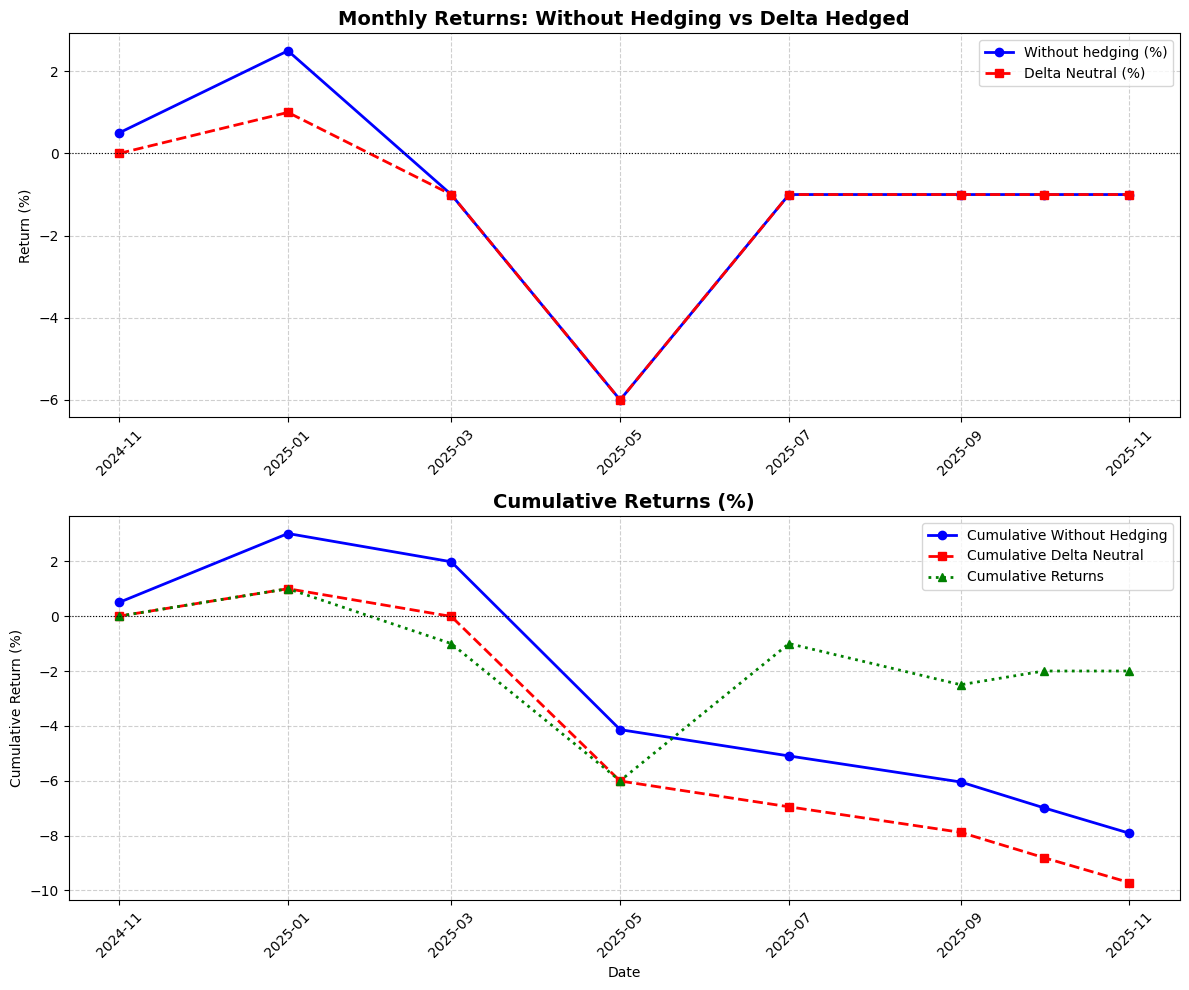

Data and Cumulative calculations:
            Without hedging  Delta_Neutral  Cumulative_Without  \
Dates                                                            
2024-11-01              0.5            0.0            0.005000   
2025-01-01              2.5            1.0            0.030125   
2025-03-01             -1.0           -1.0            0.019824   
2025-05-01             -6.0           -6.0           -0.041366   
2025-07-01             -1.0           -1.0           -0.050952   
2025-09-01             -1.0           -1.0           -0.060442   
2025-10-01             -1.0           -1.0           -0.069838   
2025-11-01             -1.0           -1.0           -0.079140   

            Cumulative_Delta  Cumulative Returns  
Dates                                             
2024-11-01          0.000000                 0.0  
2025-01-01          0.010000                 1.0  
2025-03-01         -0.000100                -1.0  
2025-05-01         -0.060094                -6.0  

In [50]:
#Comparison Plot unhedged vs delta hedged
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------- Values of the matrix----------
data = {
    'Dates': ['2024-11', '2025-01', '2025-03', '2025-05', '2025-07', '2025-09', '2025-10', '2025-11'],
    'Without hedging': [0.5, 2.5, -1.0, -6.0, -1.0, -1.0, -1.0, -1.0],
    'Delta_Neutral': [0.0, 1.0, -1.0, -6.0, -1.0, -1.0, -1.0, -1.0],  
    'Cumulative Returns': [0.0, 1.0, -1.0, -6.0, -1.0, -2.5, -2.0, -2.0]
}

df = pd.DataFrame(data)

# Turn dates into datetime (add day for smoothness)
df['Dates'] = pd.to_datetime(df['Dates'] + '-01', format='%Y-%m-%d')
df.set_index('Dates', inplace=True)

# ---------- Cumulative Returns ----------
df['Cumulative_Without'] = (1 + df['Without hedging']/100).cumprod() - 1
df['Cumulative_Delta'] = (1 + df['Delta_Neutral']/100).cumprod() - 1

# ---------- Plot ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Monthly returns (%)
axes[0].plot(df.index, df['Without hedging'], 
             marker='o', linewidth=2, label='Without hedging (%)', color='blue')
axes[0].plot(df.index, df['Delta_Neutral'], 
             marker='s', linestyle='--', linewidth=2, label='Delta Neutral (%)', color='red')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Monthly Returns: Without Hedging vs Delta Hedged', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Cumulative returns (%)
axes[1].plot(df.index, df['Cumulative_Without']*100, 
             marker='o', linewidth=2, label='Cumulative Without Hedging', color='blue')
axes[1].plot(df.index, df['Cumulative_Delta']*100, 
             marker='s', linestyle='--', linewidth=2, label='Cumulative Delta Neutral', color='red')
# Add "Cumulative Returns" for comparison
axes[1].plot(df.index, df['Cumulative Returns'],
             marker='^', linestyle=':', linewidth=2, label='Cumulative Returns', color='green')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Return (%)')
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Better display of dates
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# ---------- Display data ----------
print("Data and Cumulative calculations:")
print(df[['Without hedging', 'Delta_Neutral', 
          'Cumulative_Without', 'Cumulative_Delta', 
          'Cumulative Returns']])